#**Aula 1 - Tratando os Dados**

In [2]:
import pandas as pd

In [3]:
cadastrados = pd.read_csv('https://github.com/alura-tech/alura-tech-pos-data-science-credit-scoring-streamlit/blob/main/dados/clientes_cadastrados.csv?raw=True')

In [4]:
cadastrados.head()

,ID_Cliente,Genero,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_celular,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,M,Y,Y,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,-21474,-1134,1,0,0,0,Segurança,2.0
3,5008808,F,N,Y,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,1,0,1,1,Vendas,1.0
4,5008809,F,N,Y,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,1,0,1,1,Vendas,1.0


In [5]:
cadastrados.shape

(438557, 18)

In [6]:
cadastrados['ID_Cliente'].value_counts()

ID_Cliente
7702516    2
7602432    2
7836971    2
7213374    2
7052783    2
          ..
6840104    1
6840222    1
6841878    1
6842765    1
5008808    1
Name: count, Length: 438510, dtype: int64

In [7]:
cadastrados.duplicated().sum()

np.int64(0)

In [8]:
cadastrados['ID_Cliente'].duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
438552    False
438553    False
438554    False
438555    False
438556    False
Name: ID_Cliente, Length: 438557, dtype: bool

In [9]:
cadastrados[cadastrados['ID_Cliente'].duplicated(keep=False)].shape

(94, 18)

In [10]:
id_repetidos = cadastrados[cadastrados['ID_Cliente'].duplicated(keep=False)]['ID_Cliente']

In [11]:
df_cadastrados_limpo = cadastrados.drop(id_repetidos.index)

In [12]:
df_cadastrados_limpo.head()

,ID_Cliente,Genero,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_celular,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,M,Y,Y,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,-21474,-1134,1,0,0,0,Segurança,2.0
3,5008808,F,N,Y,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,1,0,1,1,Vendas,1.0
4,5008809,F,N,Y,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,1,0,1,1,Vendas,1.0


In [13]:
df_cadastrados_limpo['ID_Cliente'].value_counts()

ID_Cliente
6842885    1
5008804    1
5008805    1
5008806    1
5008808    1
          ..
5008843    1
5008844    1
5008846    1
5008847    1
5008849    1
Name: count, Length: 438463, dtype: int64

In [14]:
df_cadastrados_limpo.isnull().sum()

ID_Cliente                    0
Genero                        0
Tem_carro                     0
Tem_casa_propria              0
Qtd_filhos                    0
Rendimento_anual              0
Categoria_de_renda            0
Grau_escolaridade             0
Estado_civil                  0
Moradia                       0
Idade                         0
Anos_empregado                0
Tem_celular                   0
Tem_telefone_trabalho         0
Tem_telefone_fixo             0
Tem_email                     0
Ocupacao                 134177
Tamanho_familia               0
dtype: int64

In [15]:
df_cadastrados_limpo['Ocupacao'].unique()

array([nan, 'Segurança', 'Vendas', 'Contabilidade', 'Construção Civil',
       'Gerência', 'Motorista', 'Equipe principal', 'Alta tecnologia',
       'Limpeza', 'Serviço privado', 'Cozinha', 'Baixa qualificação',
       'Medicina', 'Secretariado', 'Garçom', 'RH', 'Corretor imobiliário',
       'TI'], dtype=object)

In [16]:
df_cadastrados_limpo['Ocupacao'].fillna(value='Outro', inplace=True)

C:\Users\laiss\AppData\Local\Temp\ipykernel_35416\180975226.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cadastrados_limpo['Ocupacao'].fillna(value='Outro', inplace=True)


In [17]:
df_cadastrados_limpo.nunique()

ID_Cliente               438463
Genero                        2
Tem_carro                     2
Tem_casa_propria              2
Qtd_filhos                   12
Rendimento_anual            866
Categoria_de_renda            5
Grau_escolaridade             5
Estado_civil                  5
Moradia                       6
Idade                     16379
Anos_empregado             9406
Tem_celular                   1
Tem_telefone_trabalho         2
Tem_telefone_fixo             2
Tem_email                     2
Ocupacao                     19
Tamanho_familia              13
dtype: int64

In [18]:
df_cadastrados_limpo.drop('Genero', axis=1, inplace=True)

In [19]:
df_cadastrados_limpo.drop('Tem_celular', axis=1, inplace=True)

In [20]:
df_cadastrados_limpo['Tem_carro'].unique()

array(['Y', 'N'], dtype=object)

In [21]:
df_cadastrados_limpo['Tem_casa_propria'].unique()

array(['Y', 'N'], dtype=object)

In [22]:
df_cadastrados_limpo['Tem_telefone_trabalho'].unique()

array([1, 0])

In [23]:
df_cadastrados_limpo['Tem_telefone_fixo'].unique()

array([0, 1])

In [24]:
df_cadastrados_limpo['Tem_email'].unique()

array([0, 1])

In [25]:
df_cadastrados_limpo['Tem_carro'] = df_cadastrados_limpo['Tem_carro'].replace(['Y','N'],[1,0])
df_cadastrados_limpo['Tem_casa_propria'] = df_cadastrados_limpo['Tem_casa_propria'].replace(['Y','N'],[1,0])

C:\Users\laiss\AppData\Local\Temp\ipykernel_35416\2259432855.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cadastrados_limpo['Tem_carro'] = df_cadastrados_limpo['Tem_carro'].replace(['Y','N'],[1,0])
C:\Users\laiss\AppData\Local\Temp\ipykernel_35416\2259432855.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cadastrados_limpo['Tem_casa_propria'] = df_cadastrados_limpo['Tem_casa_propria'].replace(['Y','N'],[1,0])


In [26]:
df_cadastrados_limpo.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,1,1,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,0,0,Outro,2.0
1,5008805,1,1,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,0,0,Outro,2.0
2,5008806,1,1,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,-21474,-1134,0,0,0,Segurança,2.0
3,5008808,0,1,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,0,1,1,Vendas,1.0
4,5008809,0,1,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,0,1,1,Vendas,1.0


In [27]:
# Tratamento da feature Idade
df_cadastrados_limpo['Idade']=-df_cadastrados_limpo['Idade']/365.2425

In [28]:
df_cadastrados_limpo['Anos_empregado'].value_counts()

Anos_empregado
 365243    75314
-218         262
-1678        251
-249         241
-978         240
           ...  
-12233         1
-9687          1
-5492          1
-9065          1
-5924          1
Name: count, Length: 9406, dtype: int64

In [29]:
# Tratamento da feature anos empregado
df_cadastrados_limpo['Anos_empregado']=-df_cadastrados_limpo['Anos_empregado']/365.2425

In [30]:
df_cadastrados_limpo['Anos_empregado'].value_counts()

Anos_empregado
-1000.001369    75314
 0.596864         262
 4.594208         251
 0.681739         241
 2.677673         240
                ...  
 33.492816          1
 26.522105          1
 15.036585          1
 24.819127          1
 16.219361          1
Name: count, Length: 9406, dtype: int64

In [31]:
df_cadastrados_limpo.loc[df_cadastrados_limpo['Anos_empregado']<0,'Anos_empregado']=0

In [32]:
df_cadastrados_limpo['Anos_empregado'].value_counts()

Anos_empregado
0.000000     75314
0.596864       262
4.594208       251
0.681739       241
2.677673       240
             ...  
33.492816        1
26.522105        1
15.036585        1
24.819127        1
16.219361        1
Name: count, Length: 9406, dtype: int64

In [33]:
df_cadastrados_limpo.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,1,1,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,32.868574,12.435574,1,0,0,Outro,2.0
1,5008805,1,1,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,32.868574,12.435574,1,0,0,Outro,2.0
2,5008806,1,1,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,58.793815,3.104787,0,0,0,Segurança,2.0
3,5008808,0,1,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,52.321403,8.353354,0,1,1,Vendas,1.0
4,5008809,0,1,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,52.321403,8.353354,0,1,1,Vendas,1.0


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

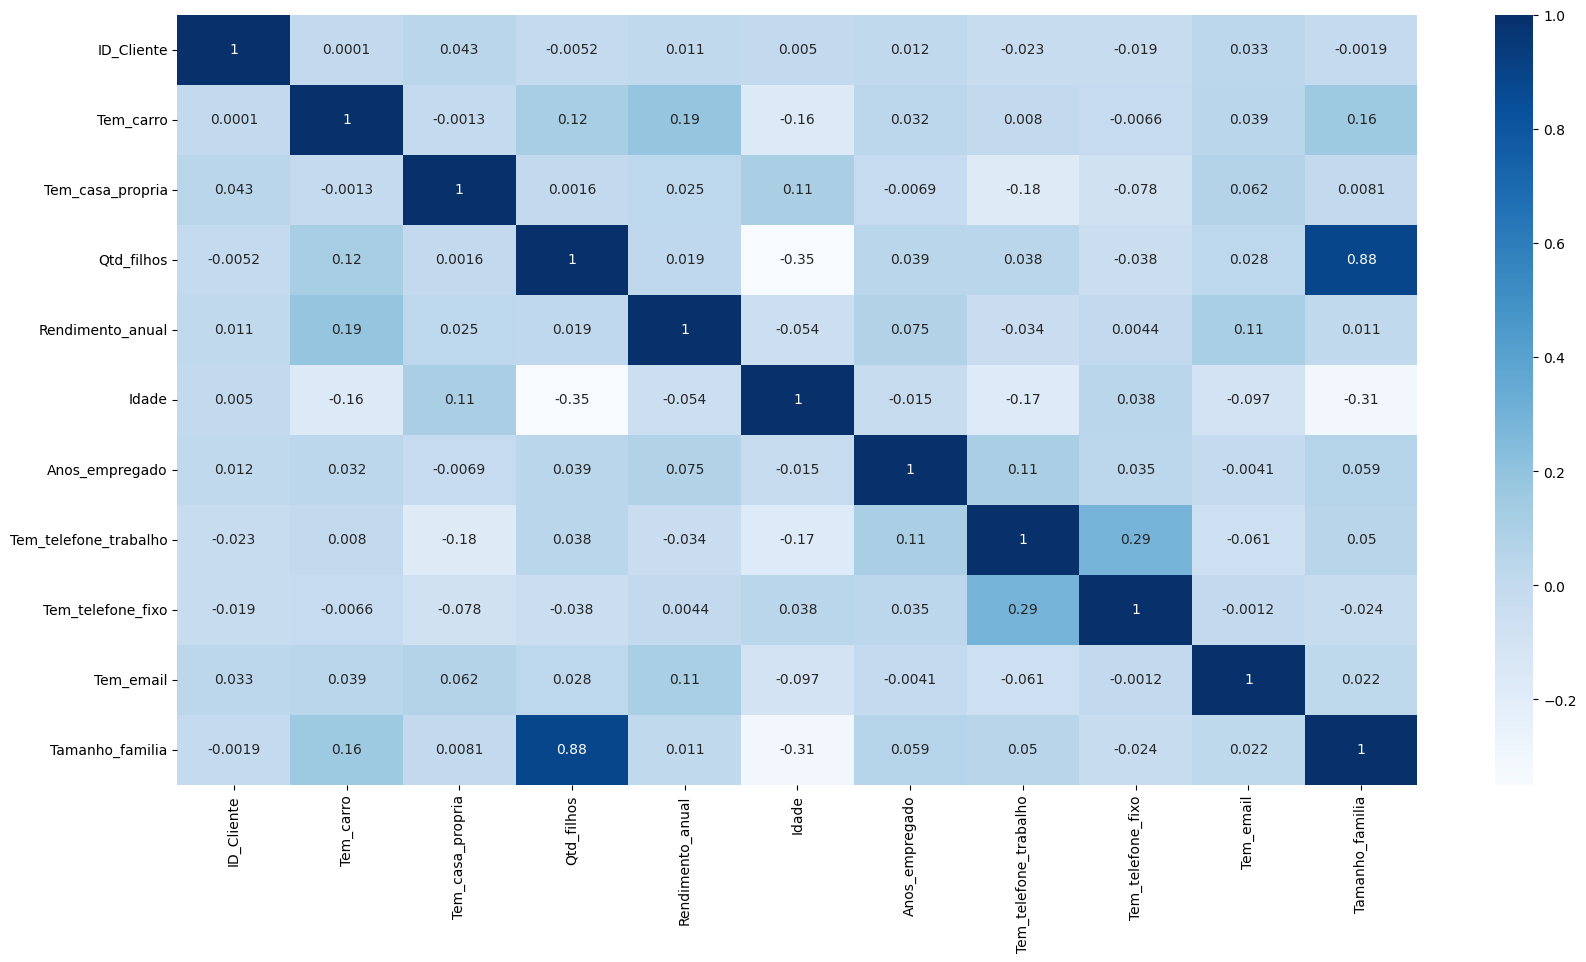

In [35]:
# A solução mais rápida: Dizer ao Pandas para USAR APENAS COLUNAS NUMÉRICAS.
corr = df_cadastrados_limpo.corr(numeric_only=True)

# O restante do código permanece o mesmo
plt.figure(figsize = (20,10))
sns.heatmap(corr, cmap="Blues", annot=True)

In [36]:
df_cadastrados_limpo.drop(['Qtd_filhos'], axis=1, inplace=True)

In [37]:
df_cadastrados_limpo=df_cadastrados_limpo[['ID_Cliente', 'Tem_carro', 'Tem_casa_propria', 
                                           'Tem_telefone_trabalho', 'Tem_telefone_fixo', 'Tem_email',
                                           'Tamanho_familia', 'Rendimento_anual', 'Idade', 'Anos_empregado',
                                           'Categoria_de_renda', 'Grau_escolaridade', 'Estado_civil',
                                           'Moradia', 'Ocupacao']]

In [38]:
df_cadastrados_limpo.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Tamanho_familia,Rendimento_anual,Idade,Anos_empregado,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Ocupacao
0,5008804,1,1,1,0,0,2.0,427500.0,32.868574,12.435574,Empregado,Ensino superior,União-estável,Apartamento alugado,Outro
1,5008805,1,1,1,0,0,2.0,427500.0,32.868574,12.435574,Empregado,Ensino superior,União-estável,Apartamento alugado,Outro
2,5008806,1,1,0,0,0,2.0,112500.0,58.793815,3.104787,Empregado,Ensino médio,Casado,Casa/apartamento próprio,Segurança
3,5008808,0,1,0,1,1,1.0,270000.0,52.321403,8.353354,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,Vendas
4,5008809,0,1,0,1,1,1.0,270000.0,52.321403,8.353354,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,Vendas


In [39]:
colunas_quantitativas = ['Tamanho_familia', 'Rendimento_anual', 'Idade', 'Anos_empregado']

In [40]:
df_cadastrados_limpo[colunas_quantitativas].describe()

,Tamanho_familia,Rendimento_anual,Idade,Anos_empregado
count,438463.000000,4.384630e+05,438463.000000,438463.000000
mean,2.194461,1.875220e+05,43.800857,5.948371
std,0.897194,1.100832e+05,11.458262,6.564112
min,1.000000,2.610000e+04,20.504186,0.000000
25%,2.000000,1.215000e+05,34.262168,1.015763
50%,2.000000,1.611000e+05,42.793487,4.019247
75%,3.000000,2.250000e+05,53.345380,8.495725
max,20.000000,6.750000e+06,68.997994,47.998248


In [41]:
df_cadastrados_limpo['Categoria_de_renda'].value_counts(normalize = True) * 100

Categoria_de_renda
Empregado              51.557144
Associado comercial    22.972520
Pensionista            17.214223
Servidor público        8.252236
Estudante               0.003877
Name: proportion, dtype: float64

In [42]:
df_cadastrados_limpo['Grau_escolaridade'].value_counts(normalize = True) * 100

Grau_escolaridade
Ensino médio                  68.821314
Ensino superior               26.797928
Ensino superior incompleto     3.385690
Ensino fundamental             0.923909
Pós-graduação                  0.071158
Name: proportion, dtype: float64

In [43]:
df_cadastrados_limpo['Estado_civil'].value_counts(normalize = True) * 100

Estado_civil
Casado           68.367912
Solteiro         12.601976
União-estável     8.329323
Divorciado        6.214663
Viúvo             4.486125
Name: proportion, dtype: float64

In [44]:
df_cadastrados_limpo['Moradia'].value_counts(normalize = True) * 100

Moradia
Casa/apartamento próprio    89.801876
Mora com os pais             4.349740
Habitação pública            3.241094
Apartamento alugado          1.362259
Apartamento comercial        0.894032
Cooperativa habitacional     0.350999
Name: proportion, dtype: float64

In [45]:
df_cadastrados_limpo['Ocupacao'].value_counts(normalize = True) * 100

Ocupacao
Outro                   30.601670
Construção Civil        17.840730
Equipe principal         9.805388
Vendas                   9.371828
Gerência                 8.091219
Motorista                5.949191
Alta tecnologia          3.941724
Contabilidade            3.644549
Medicina                 3.083042
Cozinha                  1.841432
Segurança                1.822959
Limpeza                  1.332610
Serviço privado          0.787980
Baixa qualificação       0.488069
Secretariado             0.466174
Garçom                   0.379736
Corretor imobiliário     0.237420
RH                       0.176526
TI                       0.137754
Name: proportion, dtype: float64

In [46]:
import matplotlib as mpl

In [47]:
#Configurações dos gráficos:
mpl.rcParams['font.size'] = 14
mpl.rcParams['figure.figsize'] = (10,6)

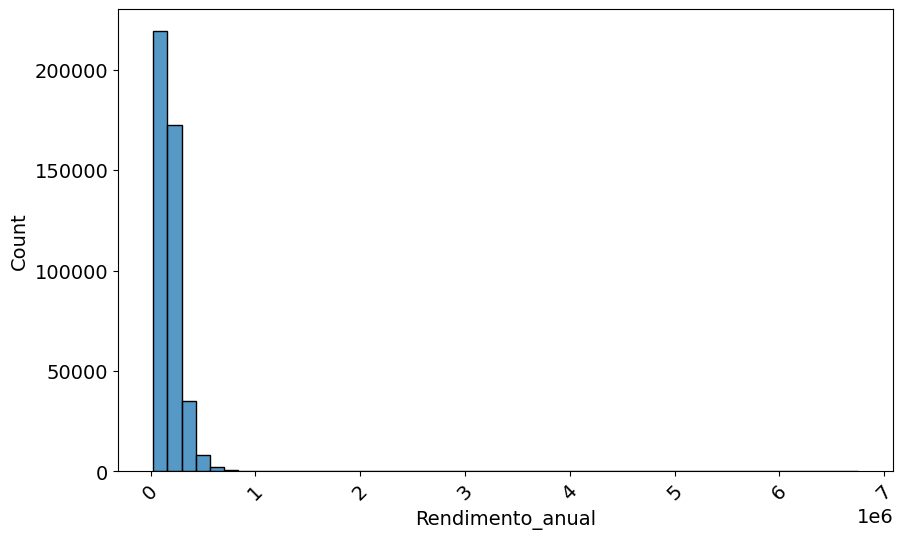

In [48]:
sns.histplot(data=df_cadastrados_limpo, x='Rendimento_anual', bins=50) 
plt.xticks(rotation=45)
plt.show()

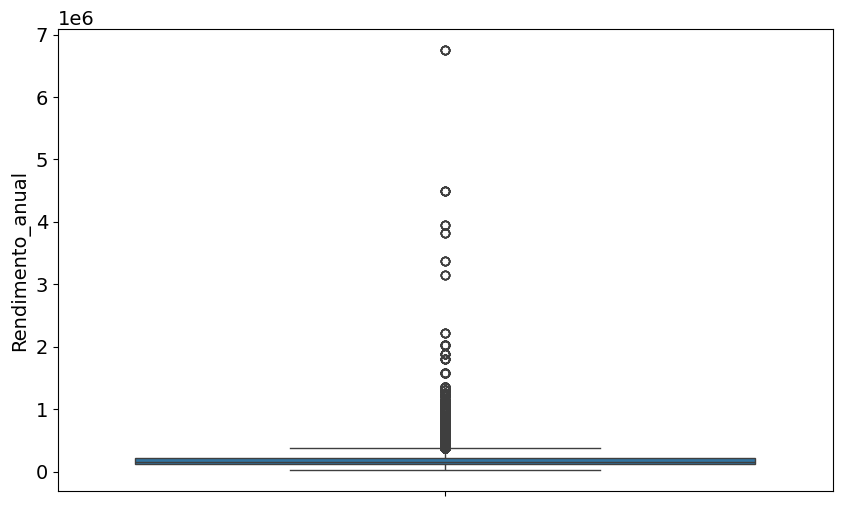

In [49]:
sns.boxplot(data=df_cadastrados_limpo, y='Rendimento_anual') 
plt.xticks(rotation=45)
plt.show()

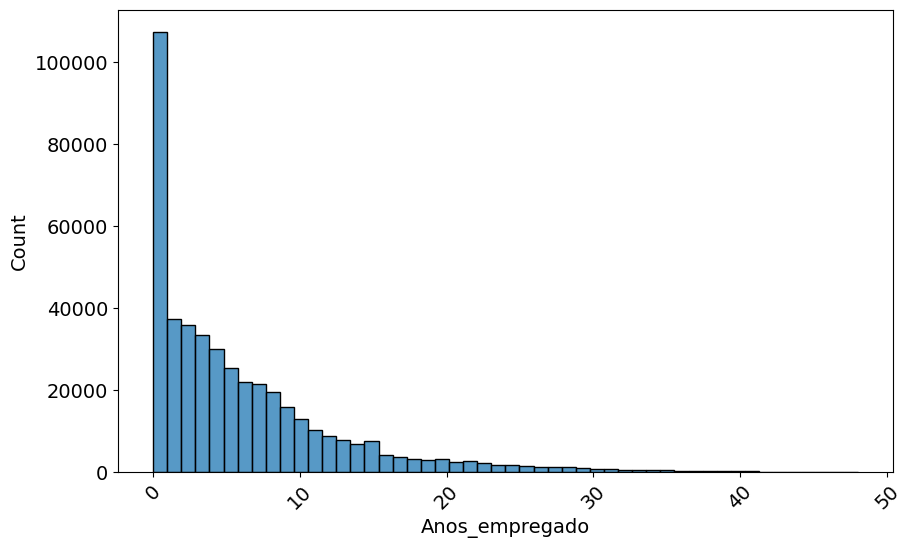

In [50]:
sns.histplot(data=df_cadastrados_limpo, x='Anos_empregado', bins=50) 
plt.xticks(rotation=45)
plt.show()

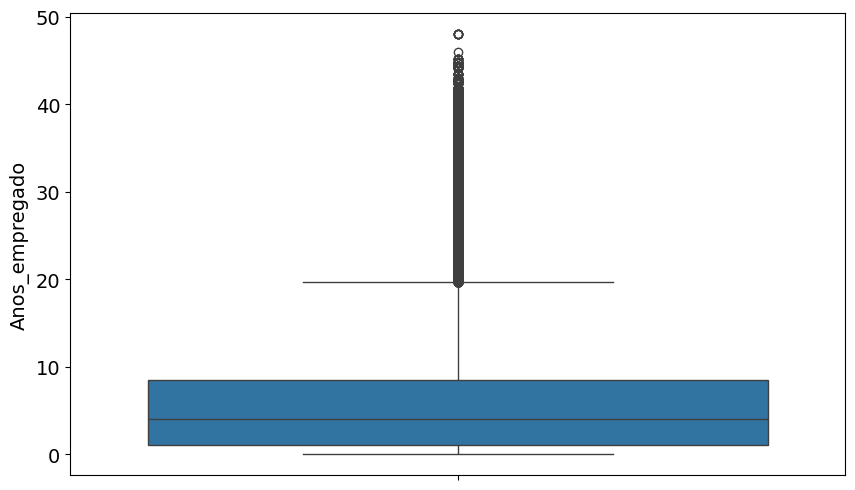

In [51]:
sns.boxplot(data=df_cadastrados_limpo, y='Anos_empregado') 
plt.xticks(rotation=45)
plt.show()

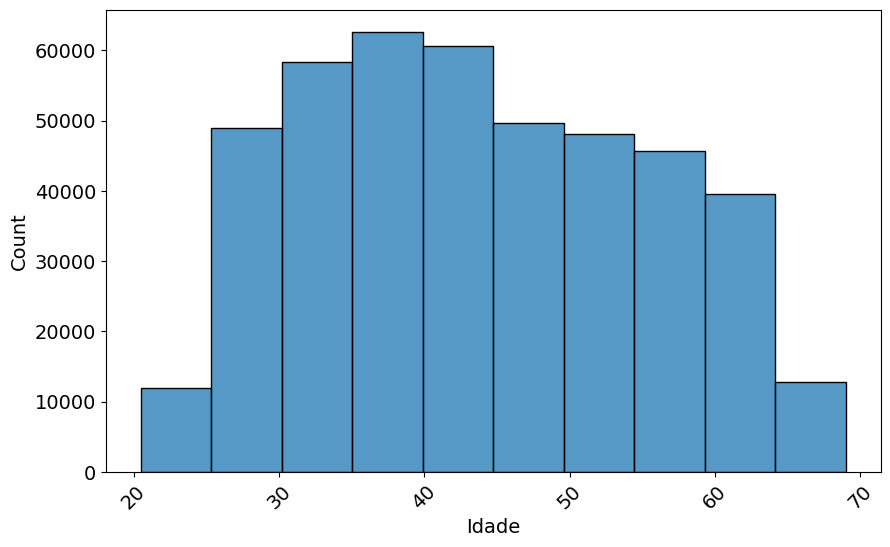

In [52]:
sns.histplot(data=df_cadastrados_limpo, x='Idade', bins=10) 
plt.xticks(rotation=45)
plt.show()

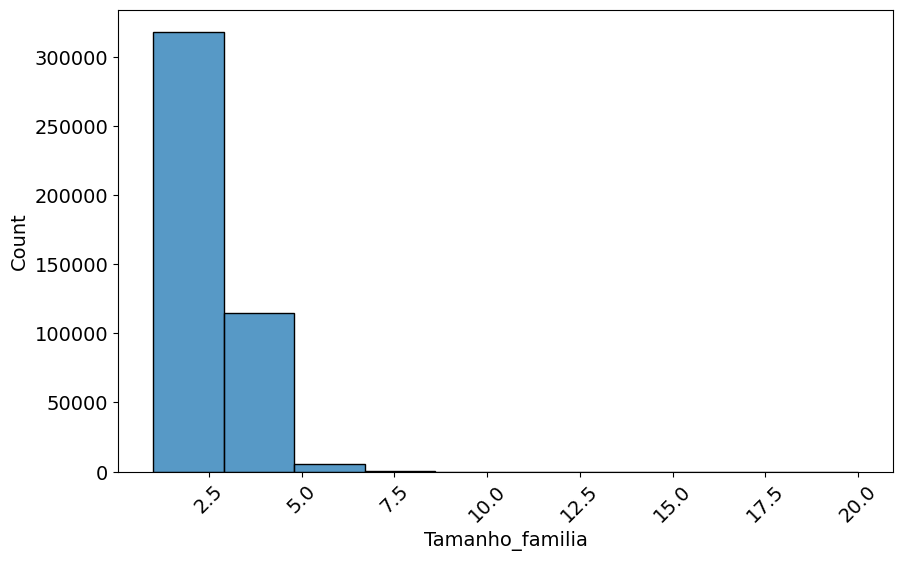

In [53]:
sns.histplot(data=df_cadastrados_limpo, x='Tamanho_familia', bins=10) 
plt.xticks(rotation=45)
plt.show()

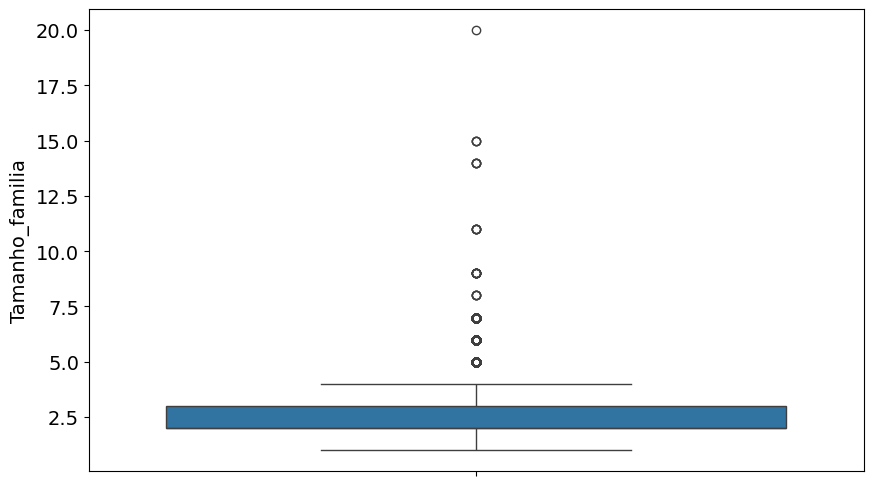

In [54]:
sns.boxplot(data=df_cadastrados_limpo, y='Tamanho_familia') 
plt.xticks(rotation=45)
plt.show()

In [55]:
'''Técnica para remoção de outliers a partir de um intervalo de confiança
o valor +- o desvio-padrão'''

coluna = df_cadastrados_limpo['Rendimento_anual']

coluna_med = coluna.mean()
coluna_std = coluna.std()

limite_sup = coluna_med + (2 * coluna_std)
limite_inf = coluna_med - (2 * coluna_std)

index_outliers = []

for index, valor in coluna.items(): 
  if valor > limite_sup or valor < limite_inf:
    index_outliers.append(index)

len(index_outliers)

12641

In [56]:
df_clientes_cadastrados_sem_outliers = df_cadastrados_limpo.drop(index_outliers)
df_clientes_cadastrados_sem_outliers.shape

(425822, 15)

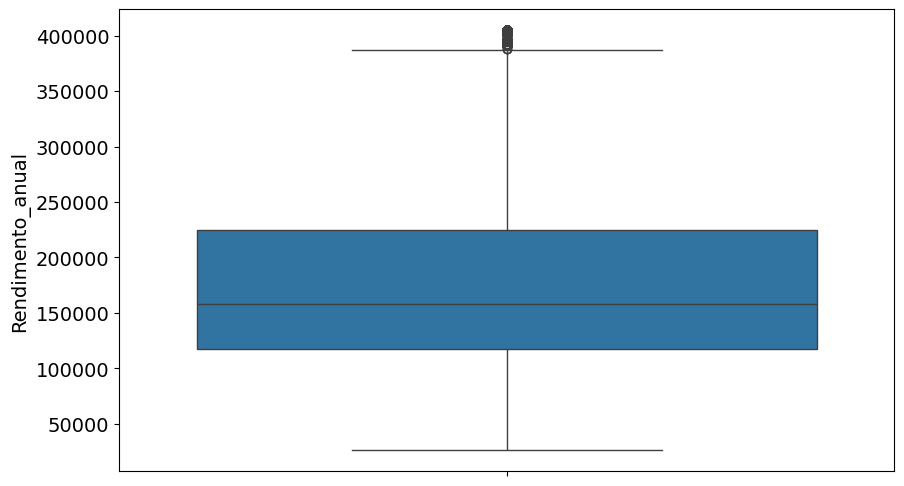

In [57]:
sns.boxplot(data=df_clientes_cadastrados_sem_outliers, y='Rendimento_anual') 
plt.xticks(rotation=45)
plt.show()

In [58]:
df_clientes_cadastrados_sem_outliers['Rendimento_anual'].max

<bound method Series.max of 2         112500.0
3         270000.0
4         270000.0
5         270000.0
6         270000.0
            ...   
438552    135000.0
438553    103500.0
438554     54000.0
438555     72000.0
438556    121500.0
Name: Rendimento_anual, Length: 425822, dtype: float64>

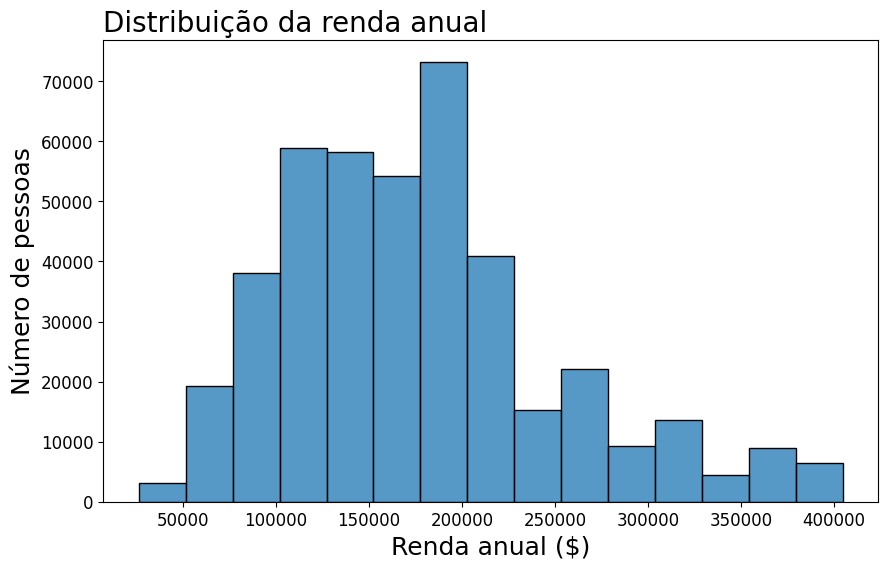

In [59]:
fig = plt.figure(figsize=(10,6))
ax = sns.histplot(data=df_clientes_cadastrados_sem_outliers, x='Rendimento_anual', bins=15)
plt.xticks(rotation=360)
ax.set_title('Distribuição da renda anual', fontsize = 20, loc='left')
ax.set_ylabel('Número de pessoas', fontsize = 18)
ax.set_xlabel('Renda anual ($)', fontsize = 18)
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)
plt.show()

In [60]:
df_clientes_cadastrados_tratamento1 = df_clientes_cadastrados_sem_outliers
df_clientes_cadastrados_tratamento1.shape

(425822, 15)

#**Aula 2 - Criando a variável Target**

In [61]:
aprovados = pd.read_csv('https://github.com/alura-tech/alura-tech-pos-data-science-credit-scoring-streamlit/blob/main/dados/clientes_aprovados.csv?raw=True')

In [62]:
aprovados.info() # para entender o que temos no arquivo

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID_Cliente      1048575 non-null  int64 
 1   Mes_referencia  1048575 non-null  int64 
 2   Faixa_atraso    1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [63]:
aprovados.head() #quantidade negativas são dias em atrasos

,ID_Cliente,Mes_referencia,Faixa_atraso
0,5001711,0,nenhum empréstimo
1,5001711,-1,1-29 dias
2,5001711,-2,1-29 dias
3,5001711,-3,1-29 dias
4,5001712,0,pagamento realizado


In [64]:
aprovados.query('ID_Cliente == 5001712') #olhando um dos clientes, para ver como isso está organizado

,ID_Cliente,Mes_referencia,Faixa_atraso
4,5001712,0,pagamento realizado
5,5001712,-1,pagamento realizado
6,5001712,-2,pagamento realizado
7,5001712,-3,pagamento realizado
8,5001712,-4,pagamento realizado
9,5001712,-5,pagamento realizado
10,5001712,-6,pagamento realizado
11,5001712,-7,pagamento realizado
12,5001712,-8,pagamento realizado
13,5001712,-9,1-29 dias


In [65]:
aprovados.query('ID_Cliente == 5001711') #analisando outro ID

,ID_Cliente,Mes_referencia,Faixa_atraso
0,5001711,0,nenhum empréstimo
1,5001711,-1,1-29 dias
2,5001711,-2,1-29 dias
3,5001711,-3,1-29 dias


In [66]:
aprovados.Faixa_atraso.value_counts()

Faixa_atraso
pagamento realizado    442031
1-29 dias              383120
nenhum empréstimo      209230
30-59 dias              11090
>150 dias                1693
60-89 dias                868
90-119 dias               320
120-149 dias              223
Name: count, dtype: int64

In [67]:
aprovados.Faixa_atraso.value_counts().index.to_list()

['pagamento realizado',
 '1-29 dias',
 'nenhum empréstimo',
 '30-59 dias',
 '>150 dias',
 '60-89 dias',
 '90-119 dias',
 '120-149 dias']

In [68]:
df_registros_creditos_agrupados_ID = aprovados.groupby('ID_Cliente') #agrupar por ID e cancular a abertura de credito dele)
ser_abertura = df_registros_creditos_agrupados_ID.apply(lambda x: min(x['Mes_referencia'])) # pegar o menor mes de movimentação do cliente para saber quando a conta foi aberta
ser_abertura.name = 'Abertura'
ser_abertura

C:\Users\laiss\AppData\Local\Temp\ipykernel_35416\1612288584.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ser_abertura = df_registros_creditos_agrupados_ID.apply(lambda x: min(x['Mes_referencia'])) # pegar o menor mes de movimentação do cliente para saber quando a conta foi aberta


ID_Cliente
5001711    -3
5001712   -18
5001713   -21
5001714   -14
5001715   -59
           ..
5150482   -28
5150483   -17
5150484   -12
5150485    -1
5150487   -29
Name: Abertura, Length: 45985, dtype: int64

In [69]:
df_clientes_aprovados = aprovados.merge(ser_abertura, on='ID_Cliente')
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura
0,5001711,0,nenhum empréstimo,-3
1,5001711,-1,1-29 dias,-3
2,5001711,-2,1-29 dias,-3
3,5001711,-3,1-29 dias,-3
4,5001712,0,pagamento realizado,-18


In [70]:
ser_final = df_registros_creditos_agrupados_ID.apply(lambda x: max(x['Mes_referencia'])) #valor maximo registrado no ID do cliente, para saber o ultimo dia de movimentação
ser_final.name = 'Final'
ser_final

C:\Users\laiss\AppData\Local\Temp\ipykernel_35416\392056102.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ser_final = df_registros_creditos_agrupados_ID.apply(lambda x: max(x['Mes_referencia'])) #valor maximo registrado no ID do cliente, para saber o ultimo dia de movimentação


ID_Cliente
5001711     0
5001712     0
5001713     0
5001714     0
5001715     0
           ..
5150482   -11
5150483     0
5150484     0
5150485     0
5150487     0
Name: Final, Length: 45985, dtype: int64

In [71]:
df_clientes_aprovados = df_clientes_aprovados.merge(ser_final, on='ID_Cliente') #merge para adicionar coluna com a informação ser_final
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final
0,5001711,0,nenhum empréstimo,-3,0
1,5001711,-1,1-29 dias,-3,0
2,5001711,-2,1-29 dias,-3,0
3,5001711,-3,1-29 dias,-3,0
4,5001712,0,pagamento realizado,-18,0


In [72]:
df_clientes_aprovados['Janela'] = df_clientes_aprovados['Final'] - df_clientes_aprovados['Abertura'] #janela/periodo de movimentação
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final,Janela
0,5001711,0,nenhum empréstimo,-3,0,3
1,5001711,-1,1-29 dias,-3,0,3
2,5001711,-2,1-29 dias,-3,0,3
3,5001711,-3,1-29 dias,-3,0,3
4,5001712,0,pagamento realizado,-18,0,18


📅 M.O.B. (Months On Book)Em português, seria Meses em Carteira ou Meses desde a Abertura.O que representa?

O MOB é um indicador crucial usado para medir o tempo de vida de um contrato de crédito, empréstimo, financiamento ou cliente dentro da carteira de uma instituição financeira.MOB 0: É o mês em que o contrato foi aprovado e o cliente entrou na carteira (o mês de abertura).MOB 1: É o primeiro mês completo após a abertura.MOB $N$: Significa que o contrato ou cliente está há $N$ meses na carteira.Qual a Importância?O MOB é fundamental para a Análise de Safra (Vintage Analysis), que é exatamente o que seu código está calculando.ConceitoMOBExplicaçãoRiscoO risco de inadimplência de um cliente muda com o MOB. Muitas vezes, a inadimplência é maior nos primeiros meses (risco de fraude) e pode subir novamente após um longo período.Safra (Vintage)O MOB permite comparar o desempenho de diferentes grupos de clientes (safras), pois ele mede o tempo de forma relativa à data de abertura, e não em datas do calendário.AcúmuloNo seu código, você usa o MOB para calcular a taxa de mau pagador de forma cumulativa, ou seja, quantos clientes se tornaram maus pagadores até o mês MOB $N$.Em resumo, o MOB é a variável temporal que permite a bancos e fintechs entenderem como o risco de crédito evolui ao longo do ciclo de vida do cliente.

In [73]:
df_clientes_aprovados['MOB'] = df_clientes_aprovados['Mes_referencia'] - df_clientes_aprovados['Abertura'] #MOB = MONTH ON BOOK
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final,Janela,MOB
0,5001711,0,nenhum empréstimo,-3,0,3,3
1,5001711,-1,1-29 dias,-3,0,3,2
2,5001711,-2,1-29 dias,-3,0,3,1
3,5001711,-3,1-29 dias,-3,0,3,0
4,5001712,0,pagamento realizado,-18,0,18,18


In [74]:
df_clientes_aprovados['Faixa_atraso'].unique()

array(['nenhum empréstimo', '1-29 dias', 'pagamento realizado',
       '30-59 dias', '60-89 dias', '90-119 dias', '120-149 dias',
       '>150 dias'], dtype=object)

In [75]:
dict_faixa_atraso_ind ={'nenhum empréstimo': 0, 'pagamento realizado': 1,
                        '1-29 dias': 2, '30-59 dias': 3, '60-89 dias': 4,
                        '90-119 dias': 5, '120-149 dias': 6, '>150 dias': 7} #criar um dicionario

In [76]:
df_clientes_aprovados['Ind_Faixa_atraso'] = df_clientes_aprovados['Faixa_atraso'].map(dict_faixa_atraso_ind)
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final,Janela,MOB,Ind_Faixa_atraso
0,5001711,0,nenhum empréstimo,-3,0,3,3,0
1,5001711,-1,1-29 dias,-3,0,3,2,2
2,5001711,-2,1-29 dias,-3,0,3,1,2
3,5001711,-3,1-29 dias,-3,0,3,0,2
4,5001712,0,pagamento realizado,-18,0,18,18,1


In [77]:
df_clientes_aprovados['Mau'] = df_clientes_aprovados.apply(lambda x: 1 if x['Ind_Faixa_atraso'] > 3 else 0, axis=1) # se maior que 3 é um mau pagador então o credito não foi aprovado e vai retornar 1 (sim)
df_clientes_aprovados.head()

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final,Janela,MOB,Ind_Faixa_atraso,Mau
0,5001711,0,nenhum empréstimo,-3,0,3,3,0,0
1,5001711,-1,1-29 dias,-3,0,3,2,2,0
2,5001711,-2,1-29 dias,-3,0,3,1,2,0
3,5001711,-3,1-29 dias,-3,0,3,0,2,0
4,5001712,0,pagamento realizado,-18,0,18,18,1,0


In [78]:
df_registros_creditos_ID = df_clientes_aprovados[['ID_Cliente','Abertura', 'Final', 'Janela']].groupby('ID_Cliente').apply(lambda x: x.iloc[0]).reset_index(drop=True) # Trazer somente as colunas solicitadas e agrupar pelo ID do cliente/ .apply(lambda x: x.iloc[0]) para pegar a primeira linha de cada cliente/
df_registros_creditos_ID

C:\Users\laiss\AppData\Local\Temp\ipykernel_35416\1150221685.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_registros_creditos_ID = df_clientes_aprovados[['ID_Cliente','Abertura', 'Final', 'Janela']].groupby('ID_Cliente').apply(lambda x: x.iloc[0]).reset_index(drop=True) # Trazer somente as colunas solicitadas e agrupar pelo ID do cliente/ .apply(lambda x: x.iloc[0]) para pegar a primeira linha de cada cliente/


,ID_Cliente,Abertura,Final,Janela
0,5001711,-3,0,3
1,5001712,-18,0,18
2,5001713,-21,0,21
3,5001714,-14,0,14
4,5001715,-59,0,59
...,...,...,...,...
45980,5150482,-28,-11,17
45981,5150483,-17,0,17
45982,5150484,-12,0,12
45983,5150485,-1,0,1


In [79]:
df_denominador = df_registros_creditos_ID.groupby('Abertura').apply(lambda X: X['ID_Cliente'].count()).reset_index() # contar o numero do cliente por abertura
df_denominador.columns = ['Abertura','Qtd_Clientes']
df_denominador

C:\Users\laiss\AppData\Local\Temp\ipykernel_35416\1302689892.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_denominador = df_registros_creditos_ID.groupby('Abertura').apply(lambda X: X['ID_Cliente'].count()).reset_index() # contar o numero do cliente por abertura


,Abertura,Qtd_Clientes
0,-60,415
1,-59,406
2,-58,440
3,-57,400
4,-56,470
...,...,...
56,-4,874
57,-3,919
58,-2,771
59,-1,686


In [80]:
df_vintage = df_clientes_aprovados.groupby(['Abertura','MOB']).apply(lambda X: X['ID_Cliente'].count()).reset_index() # contar o numero do cliente de acordo com a abertura e mob
df_vintage.columns = ['Abertura','MOB','Qtd_Clientes'] # nomeia as colunas que vão ser geradas
df_vintage

C:\Users\laiss\AppData\Local\Temp\ipykernel_35416\3743669503.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_vintage = df_clientes_aprovados.groupby(['Abertura','MOB']).apply(lambda X: X['ID_Cliente'].count()).reset_index() # contar o numero do cliente de acordo com a abertura e mob


,Abertura,MOB,Qtd_Clientes
0,-60,0,415
1,-60,1,414
2,-60,2,410
3,-60,3,408
4,-60,4,403
...,...,...,...
1886,-2,1,770
1887,-2,2,750
1888,-1,0,686
1889,-1,1,682


In [81]:
df_vintage = pd.merge(df_vintage[['Abertura','MOB']], df_denominador, on = ['Abertura'], how = 'left') #merge para unir as colunas com o data frame DF denominador, abertura é o dado em comum, e how é aond quer que seja inserido
df_vintage

,Abertura,MOB,Qtd_Clientes
0,-60,0,415
1,-60,1,415
2,-60,2,415
3,-60,3,415
4,-60,4,415
...,...,...,...
1886,-2,1,771
1887,-2,2,771
1888,-1,0,686
1889,-1,1,686


In [82]:
import numpy as np

In [83]:
# 1. Inicializa a Coluna para Contagem de Maus Pagadores
# Cria uma nova coluna chamada 'Qtd_Mau' no DataFrame 'df_vintage'.
# Ela é inicializada com valores NaN (Não é um Número) antes de ser preenchida.
df_vintage['Qtd_Mau'] = np.nan 

# Comentário: calcular a taxa de mau pagadores com base na abertura e no mob

# 2. Início do Loop Principal para Iterar sobre 'Abertura' (Tempo de Abertura)
# O loop externo itera sobre os valores de 'Abertura', variando de -60 a 0 (1 é exclusivo).
# A variável 'j' representa o valor de 'Abertura' (por exemplo, mês de abertura).
for j in range(-60, 1):
    
    # 2.1. Inicializa a Lista de Clientes Mau Pagadores
    # 'ls' será uma lista para armazenar os IDs dos clientes classificados como 'Mau' (Mau == 1)
    # para um determinado período de 'Abertura' (j) e *até* um determinado 'MOB' (i).
    ls = [] 
    
    # 3. Início do Loop Interno para Iterar sobre 'MOB' (Months on Book/Meses em Carteira)
    # O loop interno itera sobre os valores de 'MOB', variando de 0 a 60.
    # A variável 'i' representa o valor de 'MOB'.
    for i in range(0, 61):
        
        # 3.1. Consulta de Clientes Mau Pagadores
        # Realiza uma consulta no DataFrame 'df_clientes_aprovados' para encontrar:
        # - Clientes onde 'Mau' é igual a 1 (Mau Pagador).
        # - Clientes com 'MOB' igual ao valor atual de 'i'.
        # - Clientes com 'Abertura' igual ao valor atual de 'j'.
        # O resultado é uma lista dos 'ID_Cliente' que atendem a essas condições.
        due = list(df_clientes_aprovados.query('Mau == 1 and MOB == @i and Abertura == @j')['ID_Cliente'])
        
        # 3.2. Acumula os IDs dos Maus Pagadores
        # Adiciona os IDs de clientes encontrados na consulta (due) à lista acumulada 'ls'.
        # Como o loop 'i' (MOB) avança, 'ls' acumula todos os maus pagadores até aquele MOB.
        ls.extend(due) 

        # 3.3. Preenchimento da Coluna 'Qtd_Mau' no DataFrame de Vintage
        # Localiza a linha em 'df_vintage' que corresponde à combinação atual de 'MOB' (i) e 'Abertura' (j).
        # Atribui a essa célula o número de IDs únicos na lista acumulada 'ls'.
        # O uso de 'set(ls)' garante que cada cliente seja contado apenas uma vez (evita duplicatas de ID).
        df_vintage.loc[(df_vintage['MOB'] == i) & (df_vintage['Abertura'] == j), 'Qtd_Mau'] = len(set(ls))
        
# 4. Cálculo da Taxa de Mau Pagadores
# Cria a coluna 'Taxa_de_Mau' dividindo a 'Qtd_Mau' (clientes mau pagadores acumulados e únicos) 
# pela 'Qtd_Clientes' (clientes totais para aquele MOB/Abertura).
df_vintage['Taxa_de_Mau'] = df_vintage['Qtd_Mau'] / df_vintage['Qtd_Clientes']

# 5. Exibe o DataFrame Resultante
# Retorna (ou exibe) o DataFrame 'df_vintage' atualizado com as novas métricas.
df_vintage

,Abertura,MOB,Qtd_Clientes,Qtd_Mau,Taxa_de_Mau
0,-60,0,415,0.0,0.000000
1,-60,1,415,0.0,0.000000
2,-60,2,415,0.0,0.000000
3,-60,3,415,0.0,0.000000
4,-60,4,415,0.0,0.000000
...,...,...,...,...,...
1886,-2,1,771,0.0,0.000000
1887,-2,2,771,1.0,0.001297
1888,-1,0,686,0.0,0.000000
1889,-1,1,686,0.0,0.000000


In [84]:
df_vintage_pivot = df_vintage.pivot(index = 'Abertura',
                             columns = 'MOB',
                             values = 'Taxa_de_Mau')

df_vintage_pivot

MOB,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
Abertura,,,,,,,,,,,,,,,,,,,,,
-60,0.0,0.0,0.000000,0.000000,0.000000,0.002410,0.002410,0.007229,0.007229,0.009639,...,0.028916,0.028916,0.028916,0.028916,0.028916,0.028916,0.028916,0.031325,0.031325,0.031325
-59,0.0,0.0,0.000000,0.004926,0.004926,0.004926,0.007389,0.007389,0.007389,0.012315,...,0.029557,0.029557,0.029557,0.032020,0.032020,0.032020,0.032020,0.032020,0.032020,NaN
-58,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.004545,0.006818,0.006818,...,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,NaN,NaN
-57,0.0,0.0,0.000000,0.000000,0.002500,0.002500,0.002500,0.007500,0.007500,0.007500,...,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,NaN,NaN,NaN
-56,0.0,0.0,0.004255,0.004255,0.008511,0.010638,0.010638,0.017021,0.017021,0.021277,...,0.036170,0.036170,0.036170,0.036170,0.038298,0.038298,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
-4,0.0,0.0,0.000000,0.003432,0.003432,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-3,0.0,0.0,0.001088,0.001088,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-2,0.0,0.0,0.001297,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


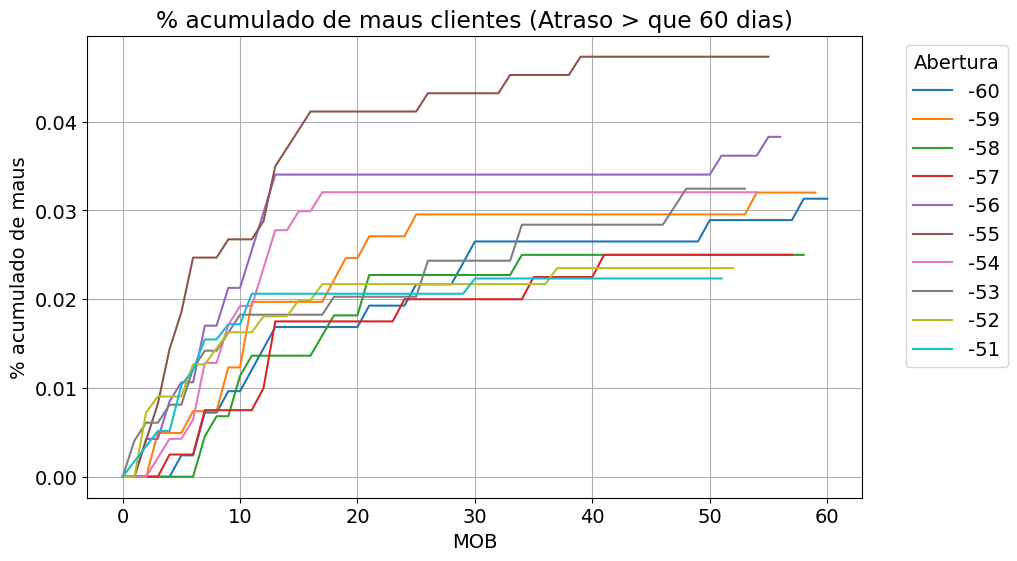

In [85]:
lst = [i for i in range(0,61)]
df_vintage_pivot[lst].T.iloc[:,:10].plot(legend = True, grid = True, title = '% acumulado de maus clientes (Atraso > que 60 dias)')

plt.xlabel('MOB')
plt.ylabel('% acumulado de maus')
plt.legend(bbox_to_anchor=(1.2, 1), title='Abertura')
plt.show()

In [86]:
!pip install spicy


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


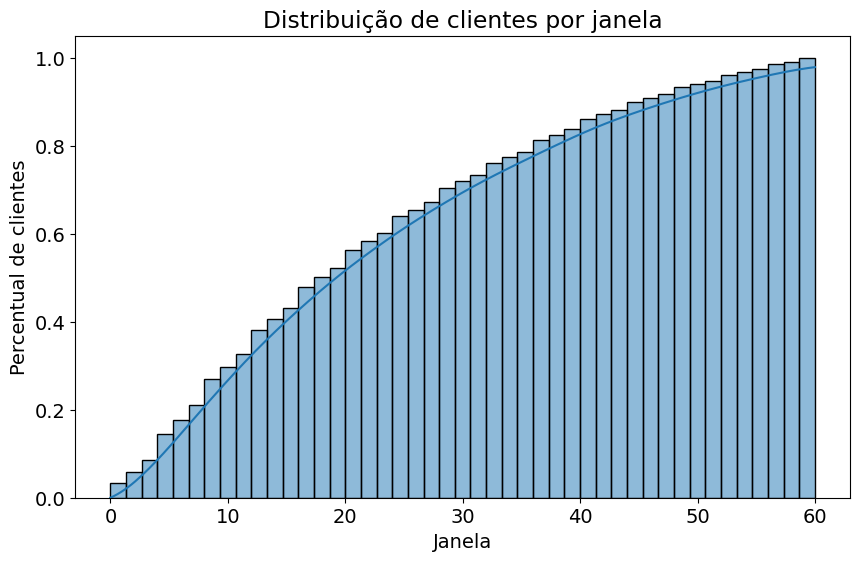

In [87]:
sns.histplot(data=df_registros_creditos_ID, x='Janela', cumulative=True, stat='density', kde=True)
plt.title('Distribuição de clientes por janela')
plt.xlabel('Janela')
plt.ylabel('Percentual de clientes')
plt.show()

In [88]:
dict_intervalo_atraso = {'maior_30_dias': 3, 'maior_60_dias': 4, 'maior_90_dias': 5,
                        'maior_120_dias': 6, 'maior_150_dias': 7} #dicionário para testar faixas de atrasos

In [89]:
for chave, valor in dict_intervalo_atraso.items():
  df_clientes_aprovados[f'Mau_{chave}'] = df_clientes_aprovados.apply(lambda x: 1 if x['Ind_Faixa_atraso'] >= valor else 0, axis=1) # mais de 60
df_clientes_aprovados.head() #instrução for para testar o intervalo de atrasos

,ID_Cliente,Mes_referencia,Faixa_atraso,Abertura,Final,Janela,MOB,Ind_Faixa_atraso,Mau,Mau_maior_30_dias,Mau_maior_60_dias,Mau_maior_90_dias,Mau_maior_120_dias,Mau_maior_150_dias
0,5001711,0,nenhum empréstimo,-3,0,3,3,0,0,0,0,0,0,0
1,5001711,-1,1-29 dias,-3,0,3,2,2,0,0,0,0,0,0
2,5001711,-2,1-29 dias,-3,0,3,1,2,0,0,0,0,0,0
3,5001711,-3,1-29 dias,-3,0,3,0,2,0,0,0,0,0,0
4,5001712,0,pagamento realizado,-18,0,18,18,1,0,0,0,0,0,0


In [90]:
dict_taxa_mau = {}
id_sum = len(set(df_clientes_aprovados['ID_Cliente']))

for chave in dict_intervalo_atraso.keys():
  df_min_mau = df_clientes_aprovados.query(f'Mau_{chave} == 1').groupby('ID_Cliente')['MOB'].min().reset_index()
  df_mob_taxa_mau = pd.DataFrame({'MOB':range(0,61), 'Taxa_Mau': np.nan})
  lst = []
  for i in range(0,61):
      due = df_min_mau.query('MOB == @i')['ID_Cliente'].to_list()
      lst.extend(due) #cumsum
      df_mob_taxa_mau.loc[df_mob_taxa_mau['MOB'] == i, 'Taxa_Mau'] = len(set(lst)) / id_sum
  dict_taxa_mau[chave] = df_mob_taxa_mau['Taxa_Mau']

df_taxa_mau = pd.DataFrame(dict_taxa_mau)
df_taxa_mau

,maior_30_dias,maior_60_dias,maior_90_dias,maior_120_dias,maior_150_dias
0,0.000304,0.000022,0.000022,0.000022,0.000022
1,0.011612,0.000174,0.000087,0.000087,0.000087
2,0.025878,0.001153,0.000196,0.000174,0.000174
3,0.036860,0.002240,0.000696,0.000304,0.000304
4,0.047385,0.003392,0.001044,0.000696,0.000348
...,...,...,...,...,...
56,0.116321,0.014483,0.007176,0.005263,0.004219
57,0.116321,0.014483,0.007176,0.005263,0.004219
58,0.116321,0.014505,0.007198,0.005284,0.004241
59,0.116321,0.014505,0.007198,0.005284,0.004241


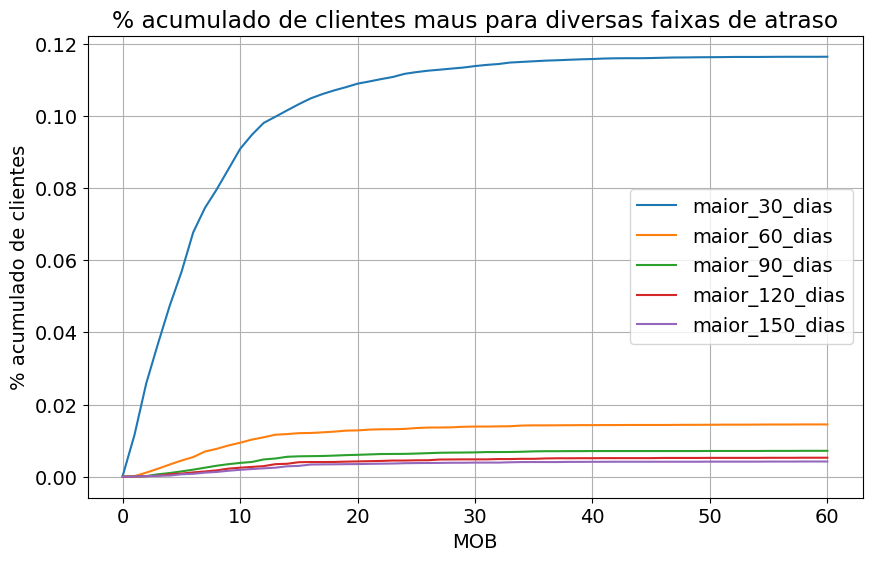

In [91]:
df_taxa_mau.plot(grid = True, title = '% acumulado de clientes maus para diversas faixas de atraso', figsize=(10, 6))
plt.xlabel('MOB')
plt.ylabel('% acumulado de clientes')
plt.show()

In [92]:
len(df_clientes_aprovados.query('Janela >= 12').groupby('ID_Cliente').count().index)

30918

In [93]:
df_clientes_aprovados_tratamento1 = df_clientes_aprovados.query('Janela >= 12').copy() #para tirar janelas menor que 12 meses
df_clientes_aprovados_tratamento1.shape

(943061, 14)

In [ ]:
def verifica(registros): # função verifica de a pessoa está acima de 60 dias é mau pagador (1) se não (0)
  lista_status = registros['Faixa_atraso'].to_list()
  if '60-89 dias' in lista_status or '90-119 dias' in lista_status or '120-149 dias' in lista_status or '>150 dias' in lista_status:
    return 1
  else:
    return 0
  
df_registros_creditos_id = pd.DataFrame(df_clientes_aprovados_tratamento1.groupby('ID_Cliente').apply(verifica)).reset_index() #apresenta e agrupa somente superior a 12 meses e verifica se ele é bom ou mau pagador
df_registros_creditos_id.columns = ['ID_Cliente', 'Mau']
df_registros_creditos_id.head()

C:\Users\laiss\AppData\Local\Temp\ipykernel_35416\3475903343.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_registros_creditos_id = pd.DataFrame(df_clientes_aprovados_tratamento1.groupby('ID_Cliente').apply(verifica)).reset_index()


,ID_Cliente,Mau
0,5001712,0
1,5001713,0
2,5001714,0
3,5001715,0
4,5001717,0


In [95]:
df_registros_creditos_id.shape

(30918, 2)

In [ ]:
df_registro_clientes_targets = df_clientes_cadastrados_tratamento1.merge(df_registros_creditos_id, on='ID_Cliente') # incluir se ele é bom ou mau pagador nos dados do cliente, puxando pelo ID do cliente
df_registro_clientes_targets.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Tamanho_familia,Rendimento_anual,Idade,Anos_empregado,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Ocupacao,Mau
0,5008806,1,1,0,0,0,2.0,112500.0,58.793815,3.104787,Empregado,Ensino médio,Casado,Casa/apartamento próprio,Segurança,0
1,5008810,0,1,0,1,1,1.0,270000.0,52.321403,8.353354,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,Vendas,0
2,5008811,0,1,0,1,1,1.0,270000.0,52.321403,8.353354,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,Vendas,0
3,5008812,0,1,0,0,0,1.0,283500.0,61.504343,0.000000,Pensionista,Ensino superior,Divorciado,Casa/apartamento próprio,Outro,0
4,5008813,0,1,0,0,0,1.0,283500.0,61.504343,0.000000,Pensionista,Ensino superior,Divorciado,Casa/apartamento próprio,Outro,0


In [97]:
df_registro_clientes_targets['Mau'].value_counts(normalize=True)*100

Mau
0    97.726673
1     2.273327
Name: proportion, dtype: float64